In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from scipy.stats import linregress
from scipy.stats import levene
from scipy.stats import f_oneway
from tabulate import tabulate
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#reading in data
url = "https://raw.githubusercontent.com/WendyR20/Data-602-Final-Project-Proposal/refs/heads/main/UnderlyingCauseofDeath_2010-2020_X72toX74.csv"



In [2]:
firearm_df = pd.read_csv(url)

In [3]:
%%capture

print(firearm_df.head())
print(firearm_df.tail())

#checking column names
print(firearm_df.columns)

In [4]:
%%capture

#deleting footnotes by removing all rows without a state
firearm_df = firearm_df.dropna(subset=['State Code'])
print(firearm_df.tail())

In [5]:
#renaming columns
firearm_df = firearm_df.rename(columns={
    "State Code": "State_code",
    "Year Code": "Year_code",
    "Ten-Year Age Groups": "Age_groups",
    "Crude Rate": "Death_Rate"
})

In [6]:
#removing unnecessary columns
firearm_df = firearm_df.drop(columns=["Notes", "State_code","Year_code", "Ten-Year Age Groups Code"], errors='ignore')
print(firearm_df.head())

     State   Age_groups    Year  Deaths  Population Death_Rate
0  Alabama  15-24 years  2010.0    50.0    678793.0        7.4
1  Alabama  15-24 years  2011.0    54.0    681235.0        7.9
2  Alabama  15-24 years  2012.0    46.0    676612.0        6.8
3  Alabama  15-24 years  2013.0    52.0    676183.0        7.7
4  Alabama  15-24 years  2014.0    45.0    671198.0        6.7


In [7]:
#creating the giffords state gun law score data frame 
law_scores = pd.DataFrame({
    "State": [
        "California","New Jersey","Connecticut","Hawaii","Maryland","Massachusetts","New York","Illinois","Rhode Island","Delaware",
        "Washington","Oregon","Colorado","Nevada","Virginia","Minnesota","New Mexico","Michigan","Pennsylvania","Vermont",
        "Maine","Wisconsin","Florida","North Carolina", "Nebraska","Indiana","South Carolina","Georgia","Arizona","Ohio",
        "Montana","Alaska","Texas","Alabama","Mississippi","Louisiana","Arkansas","Missouri","Oklahoma","Kansas",
        "Kentucky","Tennessee","West Virginia","South Dakota","North Dakota","Idaho","Wyoming","Utah","Iowa","New Hampshire"
    ],
    "Law_Score": [
        5,5,5,5,5,5,5,5,5,5,
        5,5,5,4,4,4,4,4,4,4,
        3,3,3,3,3,2,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1,
        1,1,1,1,1,1,1,1,1,1
    ]
})



In [8]:


#joining to cdc  data
merged_data = firearm_df.merge(law_scores, on="State", how="left")


print(merged_data.head())
print(merged_data.tail())

#checking for na data
has_na = merged_data['Law_Score'].isna().any()
print(f"Are there any NAs in law_score? {has_na}")

     State   Age_groups    Year  Deaths  Population Death_Rate  Law_Score
0  Alabama  15-24 years  2010.0    50.0    678793.0        7.4          1
1  Alabama  15-24 years  2011.0    54.0    681235.0        7.9          1
2  Alabama  15-24 years  2012.0    46.0    676612.0        6.8          1
3  Alabama  15-24 years  2013.0    52.0    676183.0        7.7          1
4  Alabama  15-24 years  2014.0    45.0    671198.0        6.7          1
        State   Age_groups    Year  Deaths  Population  Death_Rate  Law_Score
3762  Wyoming  65-74 years  2020.0    16.0     63814.0  Unreliable          1
3763  Wyoming  75-84 years  2012.0    10.0     22773.0  Unreliable          1
3764  Wyoming  75-84 years  2015.0    14.0     23633.0  Unreliable          1
3765  Wyoming  75-84 years  2019.0    10.0     27598.0  Unreliable          1
3766  Wyoming  75-84 years  2020.0    12.0     28948.0  Unreliable          1
Are there any NAs in law_score? False


In [9]:
%%capture

print(merged_data.dtypes)

In [10]:
%%capture

#converting columns

merged_data['Death_Rate'] = pd.to_numeric(merged_data['Death_Rate'], errors='coerce') 
merged_data['Year'] = pd.to_datetime(merged_data['Year'], format='%Y')
                                         
print(merged_data.dtypes)
                                         

In [11]:
merged_data.describe()

,Year,Deaths,Population,Death_Rate,Law_Score
count,3767,3767.000000,3.767000e+03,3045.000000,3767.000000
mean,2015-02-06 17:46:54.441199872,63.503318,7.570698e+05,11.450575,2.582692
min,2010-01-01 00:00:00,10.000000,2.198500e+04,0.500000,1.000000
25%,2012-01-01 00:00:00,24.000000,2.153670e+05,8.000000,1.000000
50%,2015-01-01 00:00:00,47.000000,4.872610e+05,10.900000,2.000000
75%,2018-01-01 00:00:00,83.000000,8.944205e+05,14.300000,4.000000
max,2020-01-01 00:00:00,407.000000,6.052952e+06,49.000000,5.000000
std,NaN,58.418041,8.895817e+05,5.345323,1.701113


## Gun Law Strength And Average Death Rates by State

In [12]:
#average death rate by state

state_table = merged_data.groupby("State")["Death_Rate"].mean().reset_index()
state_table = state_table.sort_values(by="Death_Rate", ascending=False)

state_table2 = (state_table.head(10)
                .style
                .format({"Death_Rate": "{:.2f}"})
                .hide(axis='index')
                .set_caption("Table 1: Mean Firearm Death Rate by State (Top 10)"))

display(state_table2)

State,Death_Rate
Wyoming,29.29
Alaska,24.49
North Dakota,21.45
Montana,20.24
South Dakota,19.40
Idaho,16.40
New Mexico,15.44
West Virginia,15.39
Nevada,15.12
Oklahoma,15.11


In [13]:
#let's try to make the table neater for the slides

top_10 = state_table.sort_values(by="Death_Rate", ascending=False).head(10).copy()

#renaming the columns
top_10.columns = ["State", "Death Rate"]

#trying to make a wider table so going to split the top ten into columns in the table
chunk_size = 5 
left_side = top_10.iloc[:chunk_size].reset_index(drop=True)
right_side = top_10.iloc[chunk_size:].reset_index(drop=True)

right_side.columns = ["State ", "Death Rate "] 

wide_table = pd.concat([left_side, right_side], axis=1)

#making the wide table neater
presentation_style = (wide_table.style
    .format({"Death Rate": "{:.2f}", "Death Rate ": "{:.2f}"}) 
    .hide(axis='index')
    .set_caption("Table 1: Mean Firearm Death Rate by State (Top 10)")
    .set_properties(**{
        'text-align': 'center',
        'padding': '12px 24px', 
        'font-family': 'Arial, sans-serif',
        'font-size': '14pt', 
        'border-bottom': '1px solid #dee2e6'
    })
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '18pt'), ('font-weight', 'bold'), ('margin-bottom', '15px'), ('color', '#333333')]},
        {'selector': 'th', 'props': [('background-color', '#2b5c8f'), ('color', 'white'), ('font-weight', 'bold'), ('padding', '12px')]}
    ]))



display(presentation_style)

State,Death Rate,State,Death Rate
Wyoming,29.29,Idaho,16.40
Alaska,24.49,New Mexico,15.44
North Dakota,21.45,West Virginia,15.39
Montana,20.24,Nevada,15.12
South Dakota,19.40,Oklahoma,15.11


In [14]:
#using matplotlib to create a state heat map of gun law strength


#want to use state abbreviations for the heatmap
name_to_abbrev = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR", "California": "CA",
    "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE", "Florida": "FL", "Georgia": "GA",
    "Hawaii": "HI", "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS", 
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV", "New Hampshire": "NH",
    "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY", "North Carolina": "NC",
    "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA",
    "Rhode Island": "RI", "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN",
    "Texas": "TX", "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
}

merged_data['State'] = merged_data['State'].map(name_to_abbrev)

#need to have only one law score per state thus taking the mean of the scores in our 
#dataframe for each state (essentially getting rid of the duplicates) 
#caused by the split between age-groups
merged_data2 = merged_data.groupby('State')['Law_Score'].mean().reset_index()

#have to make a state laayout using a coordinate template 
state_layout = [
    ['AK',None,None,None,None,None,None,None,None,None,None,'ME'],
    [None,None,None,None,None,None,None,None,None,'VT','NH','MA'],
    [None,'WA','ID','MT','ND','MN','IL','WI','MI','NY','CT','RI'],
    [None,'OR','NV','WY','SD','IA','IN','OH','PA','NJ','DE','MD'],
    [None,'CA','UT','CO','NE','MO','KY','WV','VA','NC','DC',None],
    [None,None,'AZ','NM','KS','AR','TN','SC','GA',None,None,None],
    [None,None,None,None,'OK','LA','MS','AL',None,None,None,None],
    ['HI',None,None,None,'TX',None,None,None,'FL',None,None,None]
]

#make the layout a dataframe
grid_df = pd.DataFrame(state_layout)
plot_data = grid_df.stack().reset_index()
plot_data.columns = ['y', 'x', 'State']


plot_data = plot_data.merge(merged_data2, on='State', how='left')

#checking to make sure the number of rows makes sense
print(f"Rows with scores: {plot_data['Law_Score'].notnull().sum()}")


matrix = plot_data.pivot(index='y', columns='x', values='Law_Score')
labels = plot_data.pivot(index='y', columns='x', values='State')



Rows with scores: 50


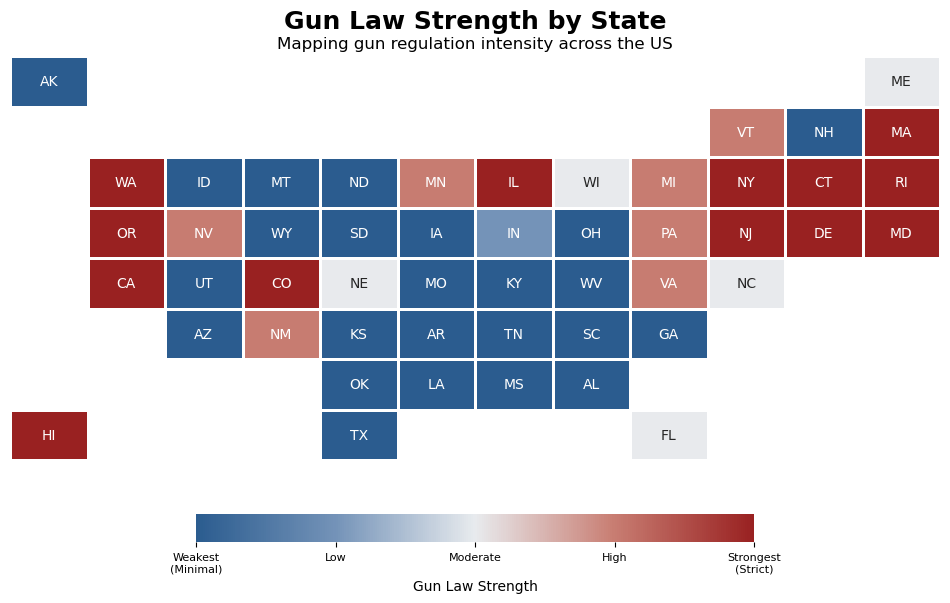

In [15]:
#custom colormap
custom_colors = ["#2b5c8f", "#7493b8", "#e8ebee", "#c87d72", "#992121"]
cmap = mcolors.LinearSegmentedColormap.from_list("gun_law", custom_colors)

#plotting the heatmap using seaborn
fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    matrix, 
    annot=labels, 
    fmt="", 
    cmap=cmap, 
    linewidths=2, 
    linecolor='white',
    cbar_kws={
        "orientation": "horizontal", 
        "pad": 0.1, 
        "shrink": 0.6,
        "label": "Gun Law Strength"
    },
    ax=ax,
    mask=matrix.isnull() #hiding any empty grid cells
)

#adding a title, 
ax.set_axis_off()
ax.set_title("Gun Law Strength by State", fontsize=18, fontweight='bold', pad=20)
plt.text(0.5, 1.02, "Mapping gun regulation intensity across the US", 
         transform=ax.transAxes, ha='center', fontsize=12)

#adding a legend for what the colors in the heatmap mean
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([1, 2, 3, 4, 5])
colorbar.set_ticklabels([
    "Weakest\n(Minimal)", "Low", "Moderate", "High", "Strongest\n(Strict)"
])
colorbar.ax.tick_params(labelsize=8)

plt.show()

In [16]:
#Creating a table of death rate by gun law strength that includes the mean, median
#standard deviation and min and max 

#average death rate for each law score
law_table = merged_data.groupby('Law_Score')['Death_Rate'].agg(['mean', 'median', 'std', 'min', 'max']).reset_index()


law_table.columns = ['Law Score', 'Average Rate', 'Median Rate', 'Std. Deviation','Minimum', 'Maximum']

law_table2 = (law_table.style
              .background_gradient(cmap='Reds', subset=['Average Rate'])
              .format(precision=2) 
              .hide(axis='index') 
              .set_properties(**{'text-align': 'center'}) 
              .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])) 

display(law_table2)

Law Score,Average Rate,Median Rate,Std. Deviation,Minimum,Maximum
1,13.46,12.90,4.78,0.50,37.50
2,10.77,10.40,2.99,4.50,20.60
3,10.39,9.90,3.41,4.50,29.30
4,11.11,9.70,5.10,3.80,49.00
5,7.87,6.15,5.53,1.40,35.50


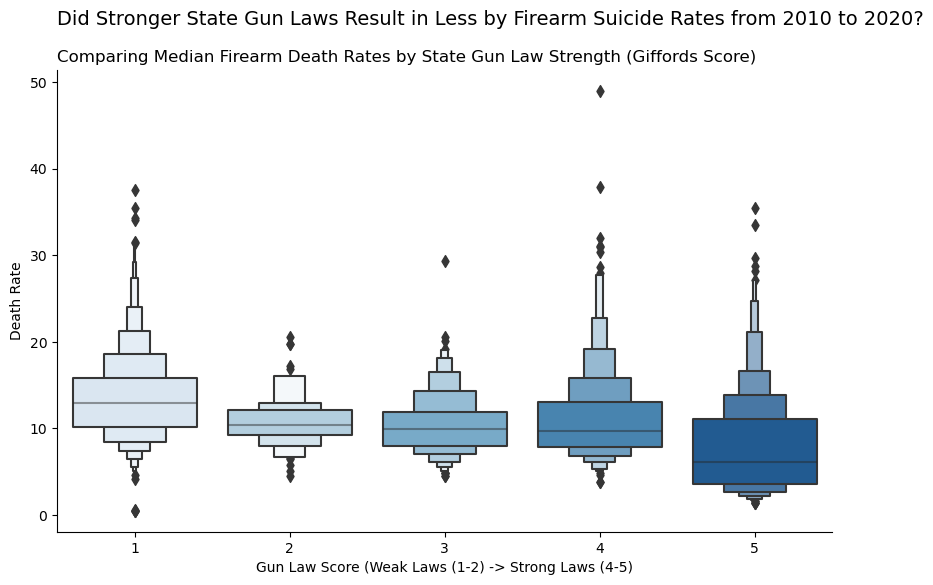

In [17]:
#creating a boxen plot of death rates by gun law strength

plt.figure(figsize=(10, 6))
sns.boxenplot(data=merged_data, x="Law_Score", y="Death_Rate", palette="Blues")

plt.suptitle("Did Stronger State Gun Laws Result in Less by Firearm Suicide Rates from 2010 to 2020?", fontsize=14, x=0.125,
             ha='left')
plt.title("Comparing Median Firearm Death Rates by State Gun Law Strength (Giffords Score)" , fontsize=12, loc='left')
plt.xlabel("Gun Law Score (Weak Laws (1-2) -> Strong Laws (4-5)")
plt.ylabel("Death Rate")
sns.despine()
plt.show()

## Suicide Rates by Age Group

In [18]:
#average death rate by age group


age_table = merged_data.groupby("Age_groups")["Death_Rate"].mean().reset_index()

age_table2 = (age_table.style
                .format({"Death_Rate": "{:.2f}"})
                .hide(axis='index')
                .set_caption("Table 1: Mean Firearm Death Rate by Age Group"))

display(age_table2)

Age_groups,Death_Rate
15-24 years,8.40
25-34 years,9.86
35-44 years,9.74
45-54 years,11.21
5-14 years,0.53
55-64 years,11.57
65-74 years,11.83
75-84 years,16.04
85+ years,17.83


In [19]:
#checking to see if the order of age-groups is the same in the dataframe as in the table
age_table["Age_groups"].unique()

array(['15-24 years', '25-34 years', '35-44 years', '45-54 years',
       '5-14 years', '55-64 years', '65-74 years', '75-84 years',
       '85+ years'], dtype=object)

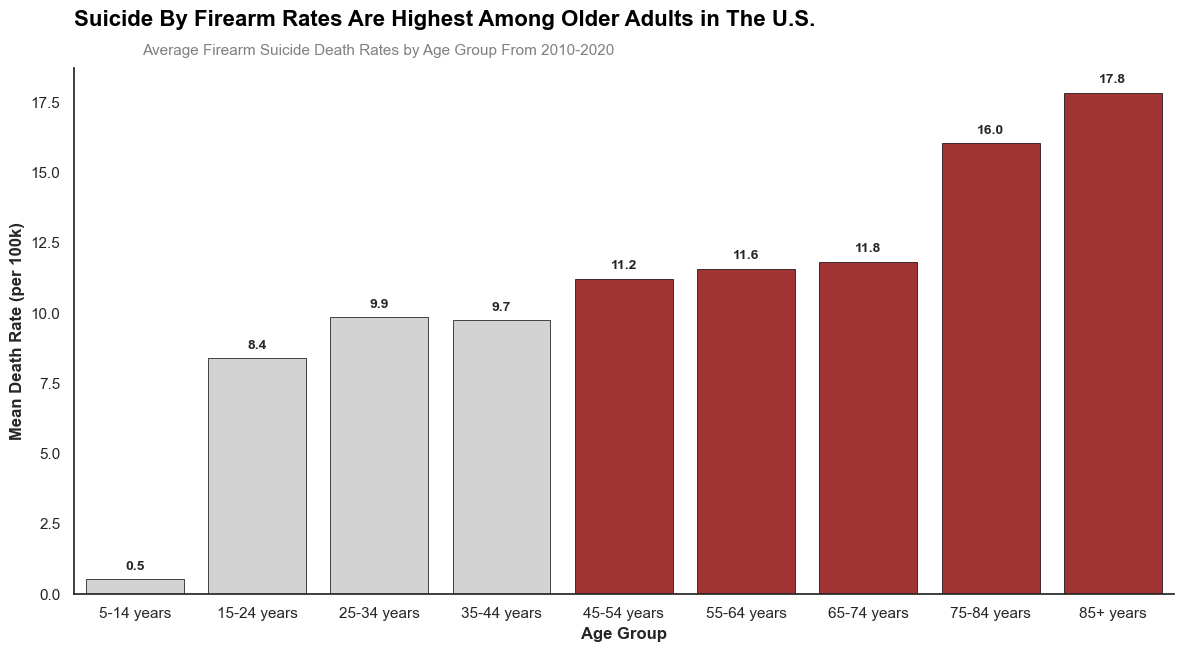

In [20]:
#creating a bar plot of age groups vs firearm suicide death rates

#first need to set the correct age group order
correct_order = ['5-14 years','15-24 years', '25-34 years', '35-44 years', '45-54 years', 
                 '55-64 years', '65-74 years', '75-84 years', '85+ years']

age_table["Age_groups"] = pd.Categorical(age_table["Age_groups"], categories=correct_order, ordered=True)
age_table = age_table.sort_values("Age_groups")


sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 7))

#highlighting bars where the Death Rate is above a certain threshold in this case 10%
highlight_colors = ["firebrick" if x > 10 else "lightgray" for x in age_table["Death_Rate"]]

bars = sns.barplot(
    data=age_table,
    x="Age_groups",
    y="Death_Rate",
    palette=highlight_colors,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

#adding the suicide death rate at the end of the bars
for p in bars.patches:
    ax.annotate(format(p.get_height(), '.1f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

# adding and formatting title, subtitle, and x and y axis labels
ax.set_title("Suicide By Firearm Rates Are Highest Among Older Adults in The U.S.",
             fontsize=16, fontweight='bold', pad=30, loc='left', color='black')

plt.suptitle("Average Firearm Suicide Death Rates by Age Group From 2010-2020",
             fontsize=11, x=0.125, y=0.88, ha='left', color='gray')

ax.set_xlabel("Age Group", fontsize=12, fontweight='bold')
ax.set_ylabel("Mean Death Rate (per 100k)", fontsize=12, fontweight='bold')


sns.despine()
plt.tight_layout()

plt.show()

## Suicide Rates Over Time

In [21]:
#average death rate by year


year_table = merged_data.groupby("Year")["Death_Rate"].mean().reset_index()

year_table2 = (year_table.style
                .format({"Death_Rate": "{:.2f}"})
                .hide(axis='index')
                .set_caption("Table 1: Mean Firearm Death Rate by Year"))

display(year_table2)

Year,Death_Rate
2010-01-01 00:00:00,10.32
2011-01-01 00:00:00,10.41
2012-01-01 00:00:00,10.85
2013-01-01 00:00:00,11.23
2014-01-01 00:00:00,11.09
2015-01-01 00:00:00,11.57
2016-01-01 00:00:00,11.81
2017-01-01 00:00:00,12.17
2018-01-01 00:00:00,12.23
2019-01-01 00:00:00,11.81


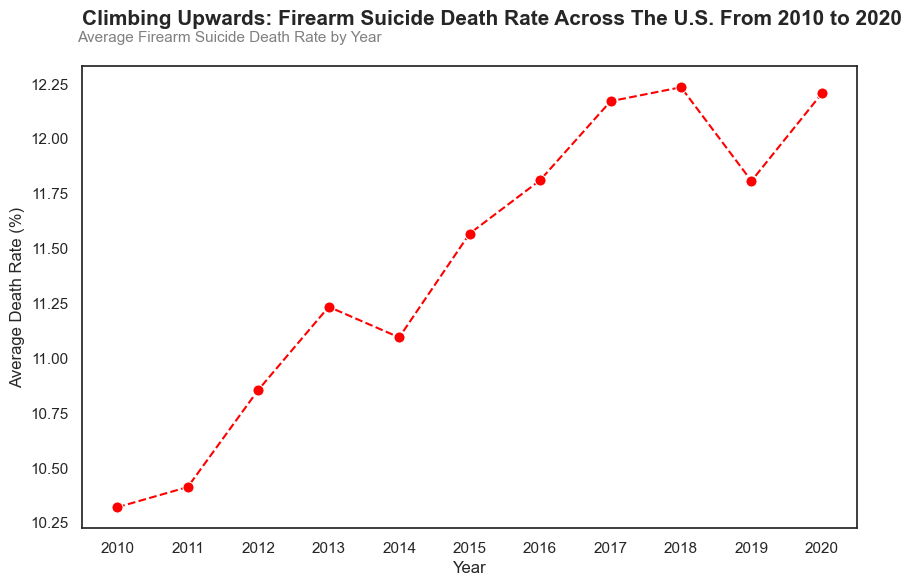

In [22]:
#making a line graph of average death rate by year using seaborn

plt.figure(figsize=(10,6))
sns.lineplot(data=year_table, x='Year', y='Death_Rate', 
            color='red', linewidth=1.5, linestyle='--', 
             marker='o', markersize=8)

plt.title("Climbing Upwards: Firearm Suicide Death Rate Across The U.S. From 2010 to 2020", 
         fontsize=15, fontweight='bold', pad=30,loc='left')
plt.suptitle("Average Firearm Suicide Death Rate by Year",
            fontsize=11, x=0.12, y=0.94, ha='left', color='gray')
plt.xlabel("Year")
plt.ylabel("Average Death Rate (%)")



plt.show()

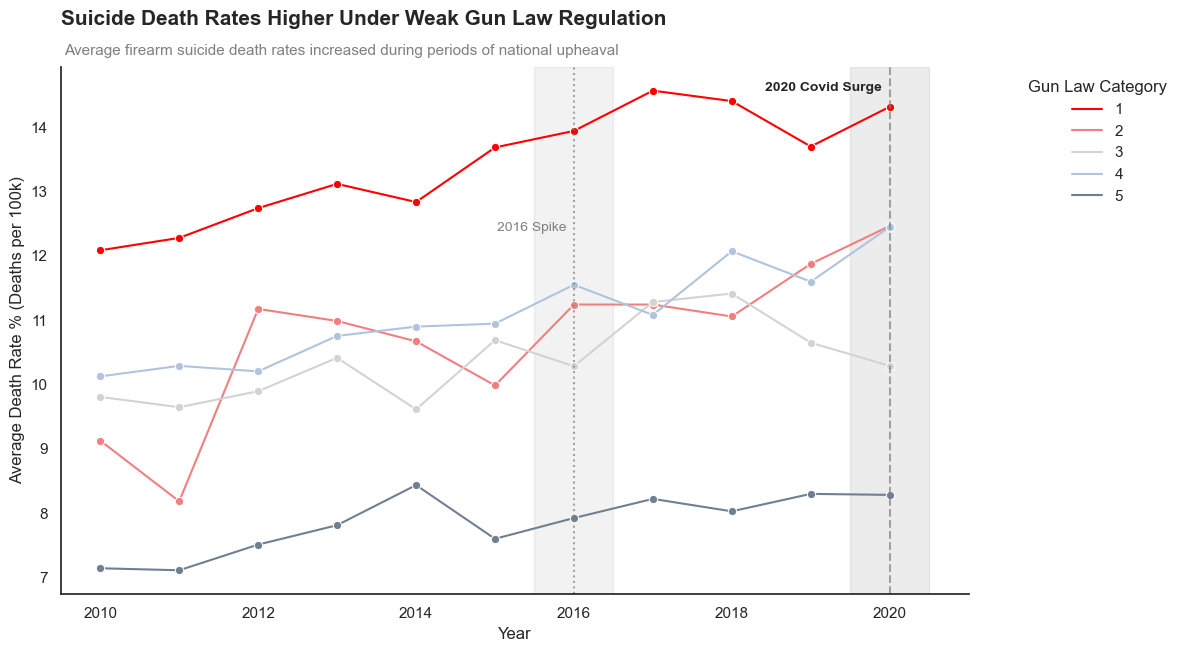

In [23]:
#now let's explore the average death rate over time by gun law strength

#we first need to group our data not only by year but also by gun law score 

#year_law = merged_data.groupby(['Year','Law_Score'])["Death_Rate"].mean().reset_index()

year_law = merged_data.groupby([merged_data['Year'].dt.year, 'Law_Score'])["Death_Rate"].mean().reset_index()

#now we can use a line graph again

#using a minimal style
#sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 7))

#adding annotations to highlight surges 
ax.axvspan(2015.5, 2016.5, color='gray', alpha=0.1, zorder=0)
ax.axvspan(2019.5, 2020.5, color='gray', alpha=0.15, zorder=0)

# 3. Plot Lines and Points
# Assuming your dataframe is named 'crude_rate'
palette = {1: "red", 2: "lightcoral", 3: "lightgray", 4: "lightsteelblue", 5: "slategray"}

sns.lineplot(
    data=year_law, 
    x='Year', 
    y='Death_Rate', 
    hue='Law_Score', 
    palette=palette, 
    linewidth=1.5, 
    marker='o',
    ax=ax
)

#
max_rate = year_law['Death_Rate'].max()

#highlighting 2016 spike
ax.axvline(x=2016, linestyle=':', color='gray', alpha=0.7)
ax.text(2015.9, max_rate * 0.85, '2016 Spike', 
        color='gray', ha='right', fontsize=10)

#highlighting covid spike in 2020
ax.axvline(x=2020, linestyle='--', color='gray', alpha=0.7)
ax.text(2019.9, max_rate, '2020 Covid Surge', 
        ha='right', fontsize=10, fontweight='bold')

#formatting x-axis
min_yr = year_law['Year'].min()
max_yr = year_law['Year'].max()

#adding room so 2020 does not get cut off
ax.set_xlim(min_yr-0.5, max_yr + 1)


ax.set_xticks(np.arange(min_yr, max_yr + 1, 2))



#adding title and subtitile 


ax.set_title("Suicide Death Rates Higher Under Weak Gun Law Regulation",
    fontsize=15, fontweight='bold', pad=30,loc='left')

plt.suptitle("Average firearm suicide death rates increased during periods of national upheaval",
    fontsize=11, x=0.06, y=0.88, ha='left', color='gray')


#adding x an y axis labels + legend
ax.set_ylabel("Average Death Rate % (Deaths per 100k)")
ax.set_xlabel("Year")
ax.legend(title="Gun Law Category", frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')

#removing spines for a clean look
sns.despine()

plt.subplots_adjust(top=0.82)

plt.tight_layout()
plt.show()

# Correlation Analysis

In [24]:
#to be able to perform a correlation analysis on our larger question
#we need to have our suicide rate data grouped by state and gun law score

state_analysis = (merged_data.groupby(['State', 'Law_Score'])['Death_Rate'].mean().reset_index())

state_analysis = state_analysis.rename(
    columns={'Death_Rate': 'Avg_Death_Rate'}
)

print(state_analysis.head())

  State  Law_Score  Avg_Death_Rate
0    AK          1       24.490909
1    AL          1       13.893750
2    AR          1       14.183784
3    AZ          1       15.037500
4    CA          5        6.820455


In [25]:
#summary statistics for our state-level suicide rates by gun law strength

print(state_analysis.describe())

       Law_Score  Avg_Death_Rate
count   50.00000       46.000000
mean     2.68000       12.269589
std      1.75476        5.227709
min      1.00000        2.881250
25%      1.00000        9.307221
50%      2.50000       12.324168
75%      4.75000       14.284181
max      5.00000       29.285714


## Is there a linear relationship between gun law strength and firearm suicide rates?

In [26]:
#using the corr() function to find the correlation between gun law score and firearm suicide rates
correlation = state_analysis['Law_Score'].corr(
    state_analysis['Avg_Death_Rate']
)

print("Correlation:", round(correlation, 3))


Correlation: -0.595


In [27]:
#tryig to get presentation ready results

# Creates a structured, presentation-ready console readout
print("=" * 45)
print(f"{'CORRELATION ANALYSIS SUMMARY':^45}")
print("=" * 45)
print(f" Variables: Law_Score vs. Avg_Death_Rate")
print(f" Pearson r: {correlation:.3f}")
print("=" * 45)

        CORRELATION ANALYSIS SUMMARY         
 Variables: Law_Score vs. Avg_Death_Rate
 Pearson r: -0.595


**Given our correlation analysis result it appears that stronger gun laws tend to be associated with lower firearm suicide death rates.**

## Regression Analysis

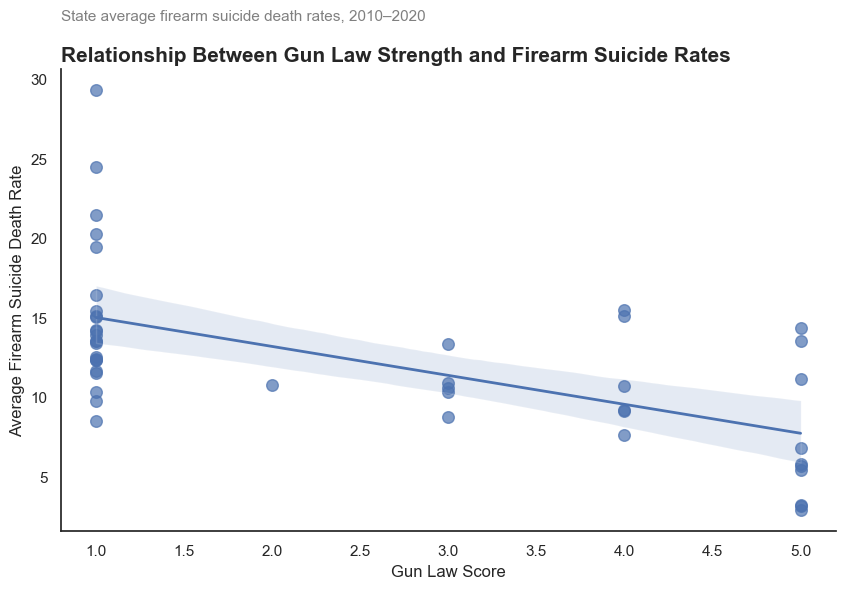

In [28]:
#creating a scatterplot of gun law score vs average death rate

plt.figure(figsize=(10,6))

sns.regplot(
    data=state_analysis,
    x='Law_Score',
    y='Avg_Death_Rate',
    scatter_kws={'s':70, 'alpha':0.7},
    line_kws={'linewidth':2}
)

plt.title(
    "Relationship Between Gun Law Strength and Firearm Suicide Rates",
    fontsize=15,
    fontweight='bold',
    loc='left'
)

plt.suptitle(
    "State average firearm suicide death rates, 2010–2020",
    fontsize=11,
    x=0.125,
    ha='left',
    color='gray'
)

plt.xlabel("Gun Law Score")
plt.ylabel("Average Firearm Suicide Death Rate")

sns.despine()

plt.show()

In [29]:
#removing rows with missing values for regression analysis
regression_data = state_analysis.dropna(
    subset=['Avg_Death_Rate', 'Law_Score'])

#running a simple linear regression 
regression = linregress(
    state_analysis['Law_Score'],
    state_analysis['Avg_Death_Rate']
)

print(regression)

print("Slope:", regression.slope)
print("R-squared:", regression.rvalue**2)
print("P-value:", regression.pvalue)

LinregressResult(slope=nan, intercept=nan, rvalue=nan, pvalue=nan, stderr=nan, intercept_stderr=nan)
Slope: nan
R-squared: nan
P-value: nan


Since our gun law strength score can only be one of five values, our data is categorical and a regression plot is not out best option. However, the earlier violin plot highlights that the median and spread of suicide death rates under strong gun law regulation (score 5) are lower and smaller than those of death rates under weaker regulation (score 1-4).

## One Way Anova Test

Given the categorical nature of our gun law strength data, we will use an Anova test to answer our research question: Is there a significant difference in suicide death rates between states with different levels of gun law strength?

The Anova test will compare of our five law score groups to determine if at least one law score group mean is significantly different from the others.

In [30]:
#we should check how large each law score group is before running the anova test
print(state_analysis['Law_Score'].value_counts())

Law_Score
1    24
5    13
4     7
3     5
2     1
Name: count, dtype: int64


In [31]:
#we need to check if there are any missing values in our dataframe before running the anova test

print(state_analysis.isna().sum())

State             0
Law_Score         0
Avg_Death_Rate    4
dtype: int64


**Since there is only one state with a score of "2", this weakens our Anova test if we run the groups as they are. Instead, we should combine some of the law score groups into broader groups.**

In [32]:
#craeting a function to combine law score groups

def law_category(score):
    if score <= 2:
        return 'Weak'  #data for scores 1-2 will be combined
    elif score == 3:
        return 'Moderate' 
    else:
        return 'Strong'  #data for scores 4-5 will be combined

state_analysis['Law_Category'] = (
    state_analysis['Law_Score']
    .apply(law_category)
)

In [33]:
#finding how large each group is
print(state_analysis['Law_Category'].value_counts())

Law_Category
Weak        25
Strong      20
Moderate     5
Name: count, dtype: int64


Though the moderate group is small, it will serve our purposes.

In [34]:
#any missing values need to be removed before running the anova test
state_analysis = state_analysis.dropna(
    subset=['Avg_Death_Rate']
)

In [35]:
#now that we have our combined law score groups we can run the anova test
#but first we have to check that the data meets the assumptions to run the anova test

groups = [
    group['Avg_Death_Rate'].values
    for name, group in state_analysis.groupby('Law_Category')
]




Prior to conducting the ANOVA test, Levene’s test was used to check that the assumption of homogeneity of variances across gun law strength groups is met. The dependent variable, average firearm suicide death rate, was continuous, and observations were treated as independent at the state level, thus meeting the two assumptions to run the Leven test.

In [36]:
#using the levene package 

stat, p_val = levene(*groups)

# Structure the text rows
results = [
    ["W-Statistic", f"{stat:.4f}"],
    ["p-value", f"{p_val:.4f}"],
    ["Assumption status", "Equal Variance Violated" if p_val < 0.05 else "Equal Variance Met"]
]

print(tabulate(results, headers=["Metric", "Value"], tablefmt="fancy_grid"))

╒═══════════════════╤════════════════════╕
│ Metric            │ Value              │
╞═══════════════════╪════════════════════╡
│ W-Statistic       │ 1.3278             │
├───────────────────┼────────────────────┤
│ p-value           │ 0.2757             │
├───────────────────┼────────────────────┤
│ Assumption status │ Equal Variance Met │
╘═══════════════════╧════════════════════╛


In [37]:
#running the anova test
anova_result = f_oneway(*groups)

print(anova_result)

F_onewayResult(statistic=9.783107487060732, pvalue=0.0003149664678009283)


In [38]:
#using the tabulate package to get the anova test results in a neater format
f_stat, p_val = f_oneway(*groups)

# Structure the output exactly like you envisioned
results = [
    ["F-Statistic", f"{f_stat:.4f}"],
    ["p-value", f"{p_val:.4f}"],
    ["Result", "Significant" if p_val < 0.05 else "Not Significant"]
]

print(tabulate(results, headers=["Metric", "Value"], tablefmt="fancy_grid"))

╒═════════════╤═════════════╕
│ Metric      │ Value       │
╞═════════════╪═════════════╡
│ F-Statistic │ 9.7831      │
├─────────────┼─────────────┤
│ p-value     │ 0.0003      │
├─────────────┼─────────────┤
│ Result      │ Significant │
╘═════════════╧═════════════╛


A one-way ANOVA was conducted to determine whether firearm suicide death rates differed across state gun law (strength) categories. Given our F-statistic (9.78) and our p-value (0.001), there is indeed a statistically significant difference between groups.  This suggests that states with different levels of gun law strength experienced significantly different average firearm suicide death rates from 2010-2020.

## Post Hoc Test: Tuskey's Test

Now that we have found that indeed there is a statistically significant difference in suicide firearm death rates between  states with differing levels gun regulation, we can determine which specific groups differ using a post hoc test. Let us use the Tukey's Honestly Significant Difference test.

In [39]:
#using the statsmodels library's pairwise_tukeyhsd function to run the test

tukey_test = pairwise_tukeyhsd(
    endog=state_analysis['Avg_Death_Rate'],
    groups=state_analysis['Law_Category'],
    alpha=0.05
)

print(tukey_test)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1  group2 meandiff p-adj   lower  upper  reject
-----------------------------------------------------
Moderate Strong  -2.0675 0.6369 -7.5814 3.4464  False
Moderate   Weak   4.1055 0.1538 -1.1668 9.3778  False
  Strong   Weak    6.173 0.0002  2.7275 9.6186   True
-----------------------------------------------------


A Tukey HSD post-hoc test was conducted following the significant ANOVA results to identify which gun law categories differed significantly in firearm suicide death rates. The analysis found that states classified as having weak gun laws had significantly higher firearm suicide death rates than states classified as having strong gun laws (p<0.001). However, differences involving moderate-law states were not statistically significant. These findings suggest that the largest differences in firearm suicide mortality occurred between states with the strongest and weakest firearm policy environments form 2010-2020.